# Task 1 — MNIST Image Classification

This notebook demonstrates the `mnist_classifier` package, which provides
three interchangeable MNIST classifiers behind a single unified API:

| Algorithm key | Class | Back-end |
|---|---|---|
| `'rf'` | `RandomForestMnistClassifier` | scikit-learn Random Forest |
| `'nn'` | `NNMnistClassifier` | PyTorch Feed-Forward Network |
| `'cnn'` | `CNNMnistClassifier` | PyTorch Convolutional Network |

---

## 1. Setup & MNIST Data Loading

In [ ]:
import sys
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('.'))

from mnist_classifier import MnistClassifier

print('Package imported successfully.')
print(f'Available algorithms: rf, nn, cnn')

Package imported successfully.
Interface ABC: <class 'mnist_classifier.interface.MnistClassifierInterface'>
Available algorithms: rf, nn, cnn


In [ ]:
from torchvision.datasets import MNIST

print('Loading MNIST dataset...')

train_ds = MNIST(root='./data', train=True,  download=True)
test_ds  = MNIST(root='./data', train=False, download=True)

X_train = train_ds.data.numpy()
y_train = train_ds.targets.numpy()
X_test  = test_ds.data.numpy()
y_test  = test_ds.targets.numpy()

print(f'X_train shape: {X_train.shape}  dtype: {X_train.dtype}')
print(f'y_train shape: {y_train.shape}  unique labels: {np.unique(y_train)}')
print(f'X_test  shape: {X_test.shape}   dtype: {X_test.dtype}')
print(f'Pixel value range: [{X_train.min()}, {X_train.max()}]')

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 146kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 907kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.7MB/s]

X_train shape: (60000, 28, 28)  dtype: uint8
y_train shape: (60000,)  unique labels: [0 1 2 3 4 5 6 7 8 9]
X_test  shape: (10000, 28, 28)   dtype: uint8
Pixel value range: [0, 255]


### Data check

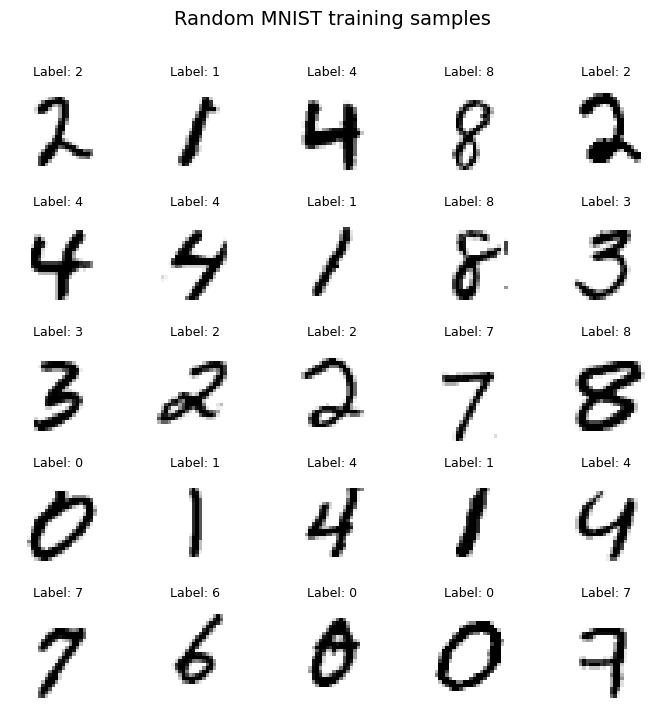

In [ ]:
rng = np.random.default_rng(seed=0)
indices = rng.choice(len(X_train), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(7, 7))
fig.suptitle('Random MNIST training samples', fontsize=14, y=1.01)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray_r')
    ax.set_title(f'Label: {y_train[idx]}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Train and Evaluate All Three Models

Each model is created through the `MnistClassifier` facade with a different
`algorithm` string.

In [ ]:
def train_and_evaluate(algorithm: str, **kwargs):
    """
    Instantiate, train, and evaluate an MnistClassifier.

    Returns
    -------
    clf : MnistClassifier   - trained classifier
    preds : np.ndarray      - predictions on X_test
    acc : float             - test accuracy
    elapsed : float         - training time in seconds
    """
    print(f"\n{'='*60}")
    print(f"  Algorithm: {algorithm.upper()}")
    print(f"{'='*60}")

    clf = MnistClassifier(algorithm=algorithm, **kwargs)

    t0 = time.time()
    clf.train(X_train, y_train)
    elapsed = time.time() - t0

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print(f"\nTest accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"Training time : {elapsed:.1f}s")
    return clf, preds, acc, elapsed

In [ ]:
clf_rf, preds_rf, acc_rf, time_rf = train_and_evaluate('rf', n_estimators=200)


  Algorithm: RF

Test accuracy : 0.9707  (97.07%)
Training time : 17.8s


In [6]:
clf_nn, preds_nn, acc_nn, time_nn = train_and_evaluate('nn', epochs=10, batch_size=64, lr=1e-3)


  Algorithm: NN


[NN] Epoch 10/10: 100%|██████████| 938/938 [00:06<00:00, 145.40batch/s, acc=0.9851, loss=0.0477]



Test accuracy : 0.9816  (98.16%)
Training time : 65.5s


In [7]:
clf_cnn, preds_cnn, acc_cnn, time_cnn = train_and_evaluate('cnn', epochs=10, batch_size=64, lr=1e-3)


  Algorithm: CNN


[CNN] Epoch 10/10: 100%|██████████| 938/938 [00:23<00:00, 39.98batch/s, acc=0.9963, loss=0.0111]



Test accuracy : 0.9910  (99.10%)
Training time : 242.0s


## 3. Accuracy Comparison

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Algorithm':     ['Random Forest', 'Feed-Forward NN', 'CNN'],
    'Key':           ['rf',            'nn',              'cnn'],
    'Test Accuracy': [acc_rf,          acc_nn,            acc_cnn],
    'Train Time (s)':[time_rf,         time_nn,           time_cnn],
})
results['Test Accuracy (%)'] = (results['Test Accuracy'] * 100).round(2)
results['Train Time (s)'] = results['Train Time (s)'].round(1)

display_cols = ['Algorithm', 'Test Accuracy (%)', 'Train Time (s)']
print(results[display_cols].to_string(index=False))

      Algorithm  Test Accuracy (%)  Train Time (s)
  Random Forest              97.07            17.8
Feed-Forward NN              98.16            65.5
            CNN              99.10           242.0


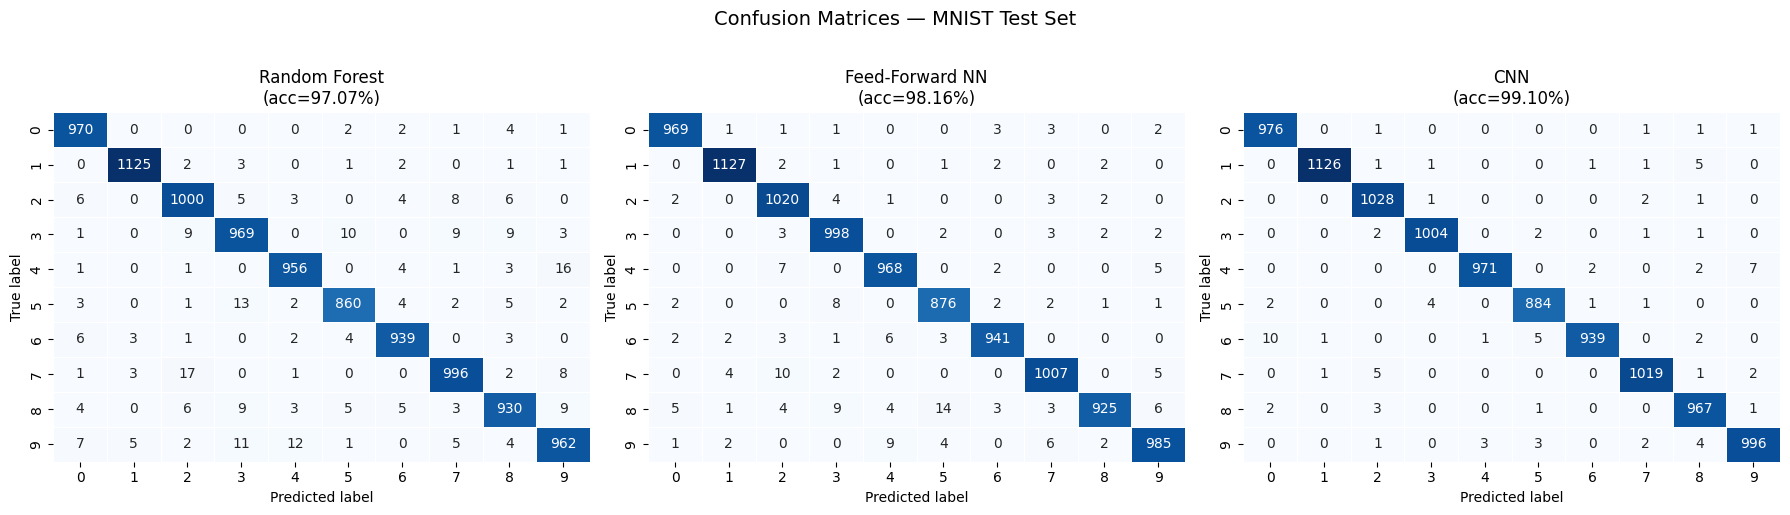

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles   = ['Random Forest', 'Feed-Forward NN', 'CNN']
all_preds = [preds_rf, preds_nn, preds_cnn]

for ax, title, preds in zip(axes, titles, all_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10),
                cbar=False, linewidths=0.5)
    ax.set_title(f'{title}\n(acc={accuracy_score(y_test, preds)*100:.2f}%)', fontsize=12)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.suptitle('Confusion Matrices — MNIST Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

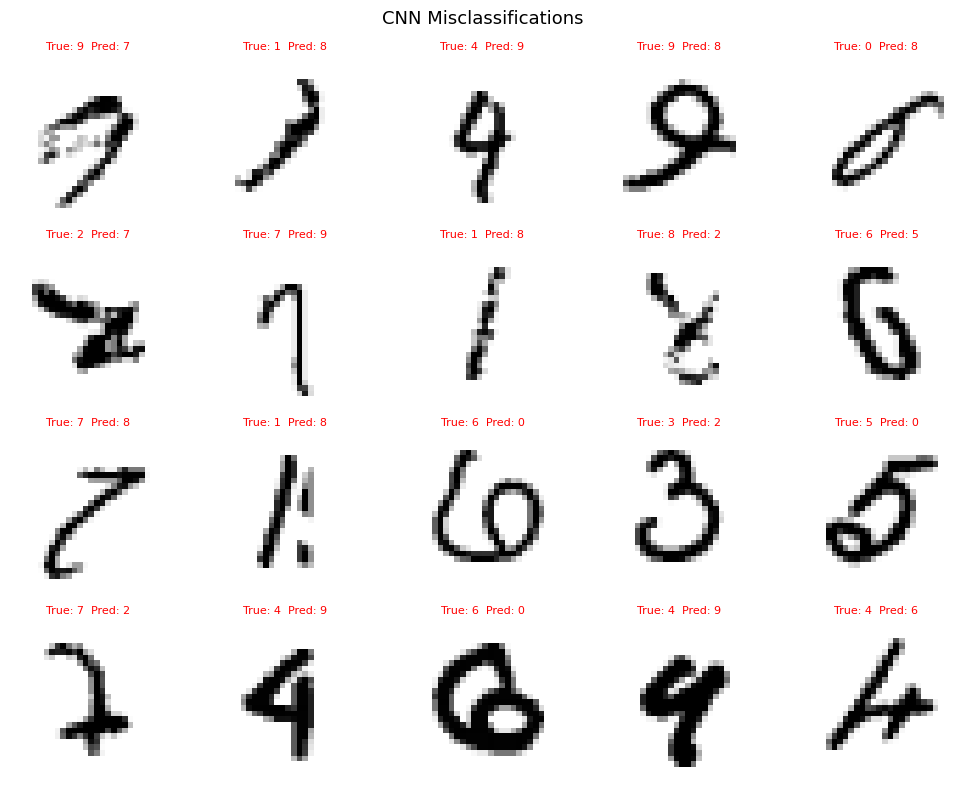

Total CNN errors on test set: 90 / 10000


In [ ]:
wrong_idx = np.where(preds_cnn != y_test)[0]
sample_wrong = rng.choice(wrong_idx, size=min(20, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle('CNN Misclassifications', fontsize=13)

for ax, idx in zip(axes.flat, sample_wrong):
    ax.imshow(X_test[idx], cmap='gray_r')
    ax.set_title(f'True: {y_test[idx]}  Pred: {preds_cnn[idx]}',
                 fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Total CNN errors on test set: {len(wrong_idx)} / {len(y_test)}')

## 4. Edge-Case Tests

A robust classifier must handle unusual or degenerate inputs gracefully.
We test the following scenarios using the CNN (the most complex model):

| # | Scenario | Description |
|---|---|---|
| 1 | All-black image | A completely dark (zero) image |
| 2 | All-white image | A fully saturated (255) image |
| 3 | Noisy image | Uniform random noise |

In [ ]:
def show_edge_case(title: str, image: np.ndarray, classifier: MnistClassifier) -> None:
    """Predict a single (28, 28) image and display it alongside the prediction."""
    # predict() expects (n, 28, 28) so add a batch dimension
    batch = image[np.newaxis]      # (1, 28, 28)
    pred  = classifier.predict(batch)[0]

    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    ax.imshow(image, cmap='gray_r', vmin=0, vmax=255)
    ax.set_title(f'{title}\nPrediction: {pred}', fontsize=9)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'  [{title}]  Predicted digit: {pred}')

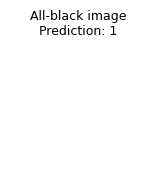

  [All-black image]  Predicted digit: 1


In [ ]:
black_img = np.zeros((28, 28), dtype=np.uint8)
show_edge_case('All-black image', black_img, clf_cnn)

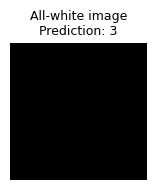

  [All-white image]  Predicted digit: 3


In [ ]:
white_img = np.full((28, 28), 255, dtype=np.uint8)
show_edge_case('All-white image', white_img, clf_cnn)

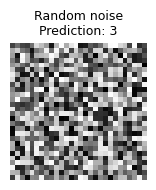

  [Random noise]  Predicted digit: 3


In [ ]:
noisy_img = rng.integers(0, 256, size=(28, 28), dtype=np.uint8)
show_edge_case('Random noise', noisy_img, clf_cnn)

## 4. Save and Load Demo

Each classifier can be persisted to disk and restored without retraining:

* **RF** → pickle (`.pkl`)
* **NN / CNN** → `torch.save` (`.pt`)

In [ ]:
import os, tempfile

tmpdir = tempfile.mkdtemp()

# ---------- Random Forest ----------
rf_path = os.path.join(tmpdir, 'rf_model.pkl')
clf_rf.save(rf_path)

clf_rf_loaded = MnistClassifier(algorithm='rf')
clf_rf_loaded.load(rf_path)
acc_rf_loaded = accuracy_score(y_test, clf_rf_loaded.predict(X_test))
print(f'RF   — original acc: {acc_rf:.4f}  |  loaded acc: {acc_rf_loaded:.4f}')
assert abs(acc_rf - acc_rf_loaded) < 1e-6, 'RF save/load accuracy mismatch!'

# ---------- CNN ----------
cnn_path = os.path.join(tmpdir, 'cnn_model.pt')
clf_cnn.save(cnn_path)

clf_cnn_loaded = MnistClassifier(algorithm='cnn')
clf_cnn_loaded.load(cnn_path)
acc_cnn_loaded = accuracy_score(y_test, clf_cnn_loaded.predict(X_test))
print(f'CNN  — original acc: {acc_cnn:.4f}  |  loaded acc: {acc_cnn_loaded:.4f}')
assert abs(acc_cnn - acc_cnn_loaded) < 1e-6, 'CNN save/load accuracy mismatch!'

print('\nAll save/load checks passed.')